# Median Filter design
We try to understand how the original design of (nfca_rx_dsp ) works

Apparently the incoming samples are stored in a shift register with 21 samples (sliding window).
The circuit has two outputs, a raw value and the baseline.

The value is obtained from the middle sample from the shift register (index 10).
The baseline is computed as the median filter of the shift register, but taking element number 12.

baseline = sorted(shift register)[12]

We create a scaled value of the baseline (that was the median filter) as the threshold
threshold = baseline * (1 - 1/32 - 1/16) 

output = raw < threshold

We are expecting to see a 848 kHz subcarrier in the incoming signal.

The signals that we use where captured by signal tap using a sampling frequency of 13.56 MHz.

Analyzing the FPGA design we see that ADC samples are incoming at a different rate of 2.5456 MHz, so we should resample them at this frequency and repeat the experiment. 

In [25]:
81.36 / 32

2.5425

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('atqa_manresa_smart_container.csv', skiprows=4)

import matplotlib.pyplot as plt

import os
print(os.getcwd())


C:\Users\2016570\OneDrive - UAB\Projects\UAB\INT_2026_TFM_Hanyu\FPGA_NFC_transceiver\analysis


In [12]:
df.head()

,time unit: s,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_tobytes:u_nfca_rx_tobytes|rx_on,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[11],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[10],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[9],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[8],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[7],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[6],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[5],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[4],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[3],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[2],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[1],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data[0],uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_ask,uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_ask_en,
0,0,X,XXXXXXXXXXXX,X,X,X,X,X,X,X,X,X,X,X,X,X,X,
1,1,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,
2,2,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,
3,3,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,
4,4,0,100101010011,1,0,0,1,0,1,0,1,0,0,1,1,1,0,


In [13]:
raw_data = df[' uart2nfca_system_top:u_uart2nfca_system|nfca_controller:u_nfca_controller|nfca_rx_dsp:u_nfca_rx_dsp|rx_raw_data']

print(raw_data[1])
def conv(s):
    try:
        v = int(s,2)
    except:
        v = 0
    return v
    
iraw_data = [conv(x) for x in raw_data[1:]]

rx = np.array(iraw_data, dtype=float)

 100101010011


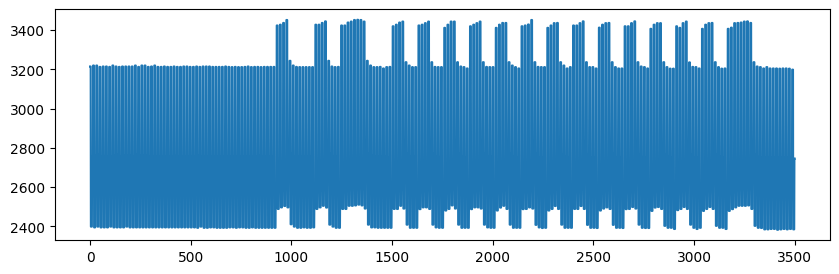

In [14]:
plt.figure(figsize=(10,3))
plt.plot(rx[1500:5000])
plt.show()

In [15]:
(1 - 1/32 - 1/256)

0.96484375

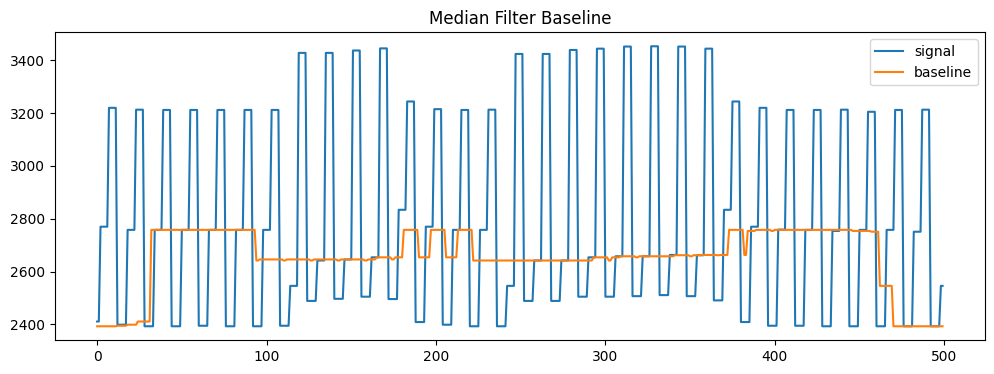

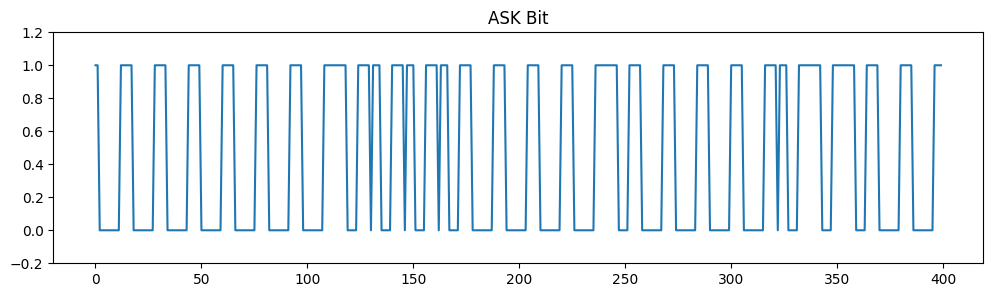

In [19]:
import numpy as np
from scipy.signal import medfilt
import matplotlib.pyplot as plt

signal =rx[1500+1000:3000]

# Median Filtering（baseline）
N = 101
MID = N // 2  
baseline = medfilt(signal, N)

# rx_ask <= ( lpf - (lpf>>5) - (lpf>>8) > raw );
threshold = baseline * 0.988
#threshold = baseline - (baseline // 32) - (baseline // 256)

# center point
raw = np.roll(signal,MID)

# ASK
bit = (raw < threshold).astype(int)

#Delete invalid points
bit = bit[MID : -MID]

plt.figure(figsize=(12,4))
plt.plot(signal, label="signal")
plt.plot(baseline, label="baseline")
plt.legend()
plt.title("Median Filter Baseline")
plt.show()

plt.figure(figsize=(12,3))
plt.plot(bit)
#plt.plot(result)
#plt.xlim(900,1500)
plt.ylim(-0.2, 1.2)
plt.title("ASK Bit")
plt.show()

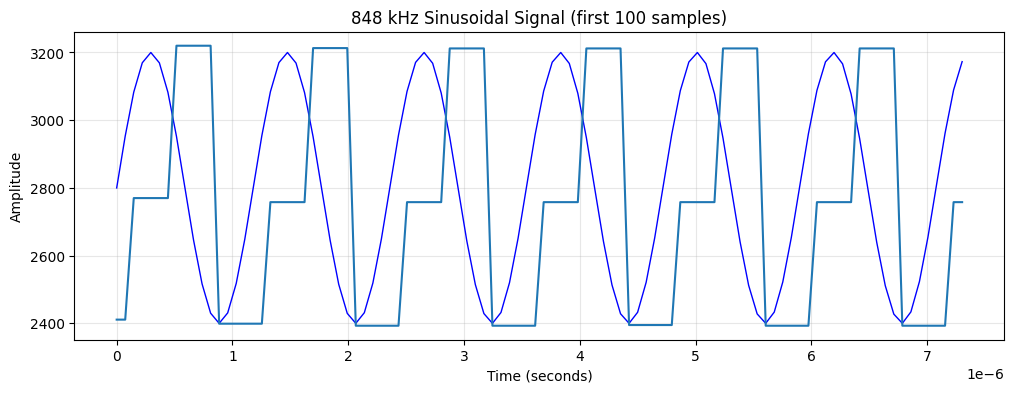

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
f_signal = 848e3      # 848 kHz signal frequency
f_sampling = 13.56e6  # 13.56 MHz sampling frequency
amplitude = 400       # Amplitude of the sinusoid
center = 2800         # Center value (DC offset)
num_samples = 500     # Number of samples

# Calculate the time array
t = np.arange(num_samples) / f_sampling

# Generate the sinusoid
s2 = center + amplitude * np.sin(2 * np.pi * f_signal * t)


# View the signal

# Optional: Plot the first few cycles
plt.figure(figsize=(12, 4))
plt.plot(t[:100], s2[:100], 'b-', linewidth=1)
plt.plot(t[:100], signal[:100], label="signal")
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.title('848 kHz Sinusoidal Signal (first 100 samples)')
plt.grid(True, alpha=0.3)
plt.show()

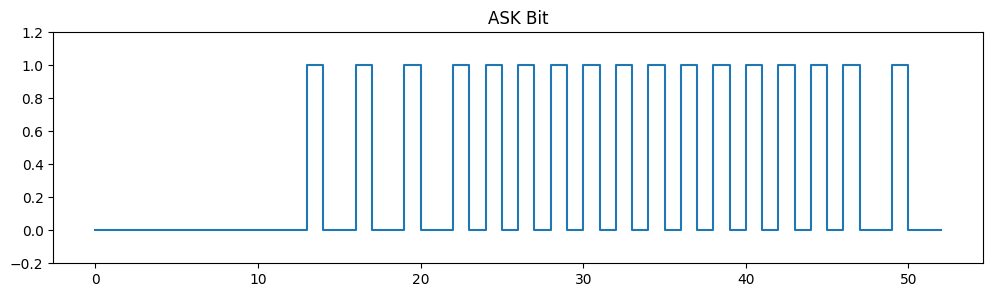

In [6]:
samples_per_bit = 64 
N = len(bit) // samples_per_bit 
bit_trim = bit[:N * samples_per_bit] 
bit_ds = (bit_trim.reshape(N, samples_per_bit).mean(axis=1) > 0.5).astype(int)

plt.figure(figsize=(12,3))
plt.step(range(len(bit_ds)), bit_ds)
#plt.plot(result)
#plt.xlim(900,1500)
plt.ylim(-0.2, 1.2)
plt.title("ASK Bit")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import medfilt

Rb = 106e3
fc = 2*Rb
Fs = 13.56e6

# 包络
rectified = np.abs(rx)
order = 5
nyquist = 0.5 * Fs
normal_cutoff = fc / nyquist
b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
envelope = signal.filtfilt(b, a, rectified)

2910.2398569962465
2725.427818397958


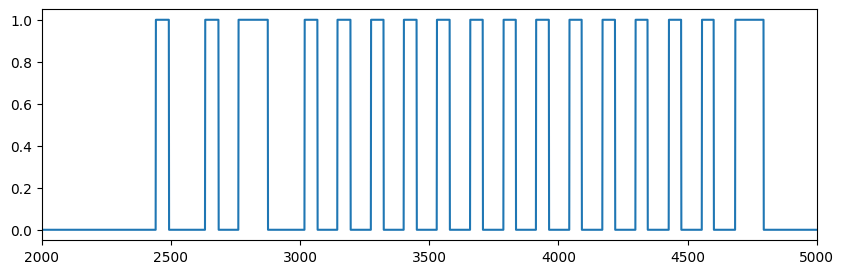

2817.8338376971024


In [8]:
envelope_max = envelope[200:2800].max()
envelope_min = envelope[200:2800].min()
print(envelope_max)
print(envelope_min)

threshold = (envelope_max + envelope_min)/2
bit = (envelope > threshold).astype(int) 

plt.figure(figsize=(10,3))
plt.xlim(2000, 5000)
plt.plot(bit)
plt.show()
print(threshold)

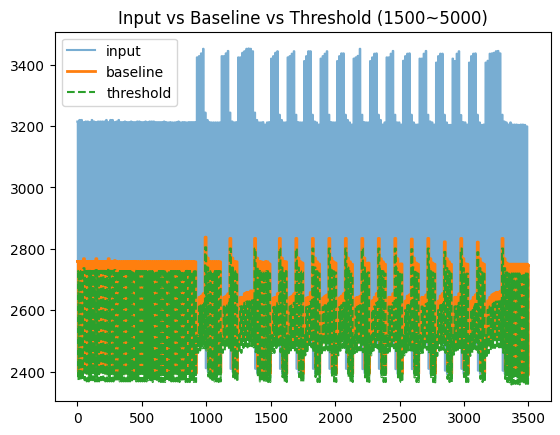

In [9]:
import numpy as np
import matplotlib.pyplot as plt
N       = 21
RAW_IDX = 10  
LPF_IDX = 12

adc = np.array(rx)   

lpf = np.array([np.median(adc[max(0,i-20):i+1]) for i in range(len(adc))])
th  = lpf - (lpf//128) - (lpf//256)   # ≈0.988*lpf

raw = np.array([adc[max(0, i-RAW_IDX)] for i in range(len(adc))])
ask = raw < th
start = 1500
end   = 5000

adc_cut = adc[start:end]
lpf_cut = lpf[start:end]
th_cut  = th[start:end]

plt.plot(adc_cut, label='input', alpha=0.6)
plt.plot(lpf_cut, label='baseline', lw=2)
plt.plot(th_cut,  '--', label='threshold')

plt.legend()
plt.title("Input vs Baseline vs Threshold (1500~5000)")
plt.show()